<a href="https://colab.research.google.com/github/vlazop/RNAP/blob/main/Preg_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Configuración del Entorno y Descarga de Datos

Antes de modelar necesitamos cargar las librerías de cómputo numérico y de aprendizaje profundo, fijar la semilla aleatoria y traer el dataset desde Kaggle. Cada paso queda aislado en su propia celda para que se pueda volver a ejecutar sin tocar el resto del notebook.

In [ ]:
# Instalación de dependencias
!pip install -q kaggle torch torchvision torcheval grad-cam scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Stdlib + cómputo numérico
import os
import random

# PyTorch: tensores, redes, optimizador, loaders
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler

# Torchvision: datasets de imágenes, modelos preentrenados, transforms
from torchvision import datasets, models, transforms

# Visualización
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# GPU si está disponible, si no CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


## 1.1 Reproducibilidad

Las redes neuronales dependen de números aleatorios para inicializar pesos, mezclar lotes y aplicar `Dropout`. Si no fijamos la semilla, dos ejecuciones del mismo código producen métricas distintas. Fijamos `SEED = 42` en Python, NumPy, PyTorch y CUDA, y pasamos un generador propio al `DataLoader` para que el muestreo sea determinístico.

In [ ]:
# Semilla global: misma red en cada corrida
SEED = 42
random.seed(SEED)            # random de Python
np.random.seed(SEED)         # NumPy
torch.manual_seed(SEED)      # PyTorch CPU
torch.cuda.manual_seed_all(SEED)  # PyTorch GPU (todas las visibles)

# cuDNN determinístico = mismo orden de ops convolucionales
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Cada worker del DataLoader hereda una semilla derivada y reproducible
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Generador propio para el sampler — controla el muestreo aleatorio del DataLoader
g = torch.Generator()
g.manual_seed(SEED)

print(f'Seed fijo: {SEED}')

Seed fijo: 42


## 1.2 Descarga del Dataset

El dataset `tire-texture-image-recognition` vive en Kaggle. Para bajarlo desde Colab subimos el archivo `kaggle.json` (la credencial de la API) al directorio actual, lo movemos a `~/.kaggle/` y lanzamos la descarga. El zip se descomprime en `tire_data/`.

In [ ]:
# Descarga del dataset desde Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jehanbhathena/tire-texture-image-recognition
!unzip -q -o tire-texture-image-recognition.zip -d tire_data/

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition
License(s): CC0-1.0
100% 708M/708M [00:42<00:00, 17.5MB/s]



# 2. Análisis de Desbalance y Mitigación

El dataset original tiene más imágenes de neumáticos sanos que dañados. Si entrenamos sin corregir esto, la red aprende a predecir siempre la clase mayoritaria y el F1 sobre la clase dañada cae. Aplicamos `WeightedRandomSampler` con peso `1/Nc` por clase para que cada mini-lote contenga, en promedio, la misma cantidad de muestras sanas y dañadas.

In [ ]:
# Transforms para entrenamiento: resize + flip aleatorio + normalización ImageNet
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                       # tamaño esperado por ResNet
    transforms.RandomHorizontalFlip(),                   # data augmentation barato
    transforms.ToTensor(),                               # PIL → tensor [0,1]
    transforms.Normalize([0.485, 0.456, 0.406],          # media RGB ImageNet
                         [0.229, 0.224, 0.225])          # desv RGB ImageNet
])

# Validación: SIN augmentation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = 'tire_data/Tire Textures/'
assert os.path.isdir(os.path.join(data_dir, 'training_data')), f'No existe {data_dir}training_data'
assert os.path.isdir(os.path.join(data_dir, 'testing_data')), f'No existe {data_dir}testing_data'

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'training_data'), transform=train_transforms)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'testing_data'), transform=val_transforms)

print(f'Clases detectadas: {train_dataset.classes}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

# --- MITIGACIÓN DE DESBALANCE ---
targets = torch.tensor(train_dataset.targets)
class_sample_count = torch.tensor([(targets == t).sum() for t in torch.unique(targets, sorted=True)])
print(f'Conteo por clase (train): {class_sample_count.tolist()}')

weight = 1. / class_sample_count.float()
samples_weight = torch.tensor([weight[t] for t in targets])
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

# --- CONFIG OPTIMIZADA PARA T4 GPU (16GB VRAM) ---
# BATCH_SIZE=64: aprovecha la VRAM de T4 sin desbordar (~9GB usados con ResNet-50)
# num_workers=2: 2 procesos cargan/decodifican imágenes en paralelo con la GPU
# pin_memory=True: memoria fijada → transferencia CPU→GPU más rápida
# persistent_workers=True: los workers no se recrean en cada época (ahorra setup)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, persistent_workers=True,
                          worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True, persistent_workers=True,
                        worker_init_fn=seed_worker, generator=g)

Clases detectadas: ['cracked', 'normal']
Train: 703 | Val: 325
Conteo por clase (train): [327, 376]


# 3. Definición de Arquitecturas

Comparamos dos enfoques. La `CustomCNN` es la línea base: tres bloques `Conv→ReLU→MaxPool` y un clasificador denso, entrenada desde cero. La `ResNet-50` viene con pesos de ImageNet; congelamos el cuerpo residual y entrenamos solo el clasificador final para reutilizar los filtros ya aprendidos sobre bordes y texturas.

In [ ]:
# Arquitectura 1: CNN entrenada desde cero (baseline)
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Extractor: 3 bloques Conv→ReLU→MaxPool
        # Cada MaxPool divide HxW entre 2:  224 → 112 → 56 → 28
        # Canales crecen: 3 → 32 → 64 → 128
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 224 → 112
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112 → 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 56  → 28
        )

        # Clasificador denso: aplana mapas y proyecta a 1 logit
        # 128*28*28 = 100352 entradas → 128 ocultas → 1 salida
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),     # regularización fuerte: 50% de neuronas apagadas en train
            nn.Linear(128, 1)    # logit binario (lo combina BCE/Focal con sigmoide)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.fc_layers(x)
        return x

In [ ]:
# Arquitectura 2: ResNet-50 con transfer learning
def get_resnet50_model():
    # Pesos preentrenados en ImageNet (1.2M imágenes, 1000 clases)
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Congelar TODO el backbone: no actualizamos los filtros convolucionales
    # Esto reusa las representaciones aprendidas y acelera la convergencia
    for param in model.parameters():
        param.requires_grad = False

    # Reemplazar la cabeza original (1000 clases) por una cabeza binaria propia
    # 2048 = dim del vector residual final de ResNet-50
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),  # 2048 → 256
        nn.ReLU(),
        nn.Dropout(0.3),           # regularización suave (red ya generaliza bien)
        nn.Linear(256, 1)          # logit binario
    )
    # Como `model.fc` se acaba de crear, sus pesos tienen requires_grad=True
    # → solo este bloque se entrena
    return model

# 4. Funciones de Pérdida y Bucle de Entrenamiento

El estudio de ablación compara dos funciones de pérdida sobre la misma arquitectura ResNet-50. `BCEWithLogitsLoss` es la pérdida estándar para clasificación binaria. `Focal Loss` añade el factor $(1-p_t)^\gamma$ para reducir el peso de los ejemplos fáciles y forzar al modelo a concentrarse en los casos difíciles:

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

Usamos $\alpha=1$ y $\gamma=2$, valores estándar del paper original.

In [ ]:
# Focal Loss: BCE re-pesada por dificultad del ejemplo
# FL(pt) = -alpha * (1-pt)^gamma * log(pt)
# - gamma=2: ejemplo fácil (pt alto) → (1-pt)^2 ≈ 0 → contribución casi nula
# - gamma=0: equivale a BCE estándar
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # BCE elemento por elemento (sin reducir)
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        # pt = prob asignada a la clase correcta. Truco: pt = exp(-BCE)
        pt = torch.exp(-BCE_loss)
        # Factor modulador (1-pt)^gamma castiga ejemplos difíciles
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()


# Bucle de entrenamiento genérico — sirve para cualquier modelo y criterio
def train_model(model, train_loader, criterion, optimizer, num_epochs=10, tag=''):
    model.to(device)
    history = {'train_loss': []}  # registro por época para graficar luego

    for epoch in range(num_epochs):
        model.train()              # activa Dropout y BatchNorm en modo train
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            # labels: (B,) int → (B,1) float para BCE/Focal con logits
            labels = labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()       # limpia gradientes acumulados
            outputs = model(inputs)     # forward → logits
            loss = criterion(outputs, labels)
            loss.backward()             # backprop
            optimizer.step()            # actualiza pesos

            # Acumulamos la pérdida ponderada por tamaño de batch
            running_loss += loss.item() * inputs.size(0)

        # Promedio sobre el dataset completo (no sobre batches)
        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        print(f'[{tag}] Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}')

    return history


# Criterios usados en el estudio de ablación
bce_criterion = nn.BCEWithLogitsLoss()  # baseline
focal_criterion = FocalLoss(alpha=1, gamma=2)  # propuesto

# 5. Evaluación

`evaluate_model` corre el modelo sobre el set de validación y devuelve un diccionario con las cinco métricas pedidas: accuracy, precision, recall, F1 y AUC-ROC. También dibuja la matriz de confusión. Devolver el dict permite comparar modelos sin repetir el código de evaluación.

In [ ]:
# Evalúa un modelo en val_loader y retorna dict con métricas
# plot_cm=True dibuja la matriz de confusión
def evaluate_model(model, val_loader, plot_cm=True, title_suffix=''):
    model.eval()  # apaga Dropout/BN para inferencia estable
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():  # sin gradientes → más rápido y menos memoria
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs)
            # Logits → probabilidad con sigmoide
            # view(-1) aplana incluso si el batch es 1 (evita bug del .squeeze())
            probs = torch.sigmoid(outputs).view(-1)
            # Umbral fijo 0.5 para decidir clase
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    # Las 5 métricas pedidas. zero_division=0 evita warnings cuando una clase
    # nunca es predicha
    metrics = {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall':    recall_score(all_labels, all_preds, zero_division=0),
        'f1':        f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc':   roc_auc_score(all_labels, all_probs),  # usa probs, no preds
    }

    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"AUC-ROC:   {metrics['auc_roc']:.4f}")

    if plot_cm:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicción')
        plt.ylabel('Real')
        plt.title(f'Matriz de Confusión {title_suffix}'.strip())
        plt.show()

    return metrics

# 6. Entrenamiento: CustomCNN con Focal Loss

Entrenamos la red desde cero durante 50 épocas. Es el baseline contra el que comparamos el transfer learning. 50 épocas son razonables: la red parte de pesos aleatorios y necesita tiempo para que los filtros convolucionales aprendan algo útil sobre las texturas.

Entrenando CustomCNN con Focal Loss (50 épocas)...
[CustomCNN-FL] Epoch 1/50 - Loss: 0.4986
[CustomCNN-FL] Epoch 2/50 - Loss: 0.1674
[CustomCNN-FL] Epoch 3/50 - Loss: 0.1688
[CustomCNN-FL] Epoch 4/50 - Loss: 0.1637
[CustomCNN-FL] Epoch 5/50 - Loss: 0.1437
[CustomCNN-FL] Epoch 6/50 - Loss: 0.1414
[CustomCNN-FL] Epoch 7/50 - Loss: 0.1404
[CustomCNN-FL] Epoch 8/50 - Loss: 0.1386
[CustomCNN-FL] Epoch 9/50 - Loss: 0.1276
[CustomCNN-FL] Epoch 10/50 - Loss: 0.1314
[CustomCNN-FL] Epoch 11/50 - Loss: 0.1144
[CustomCNN-FL] Epoch 12/50 - Loss: 0.1052
[CustomCNN-FL] Epoch 13/50 - Loss: 0.1058
[CustomCNN-FL] Epoch 14/50 - Loss: 0.1067
[CustomCNN-FL] Epoch 15/50 - Loss: 0.0984
[CustomCNN-FL] Epoch 16/50 - Loss: 0.1014
[CustomCNN-FL] Epoch 17/50 - Loss: 0.0881
[CustomCNN-FL] Epoch 18/50 - Loss: 0.0788
[CustomCNN-FL] Epoch 19/50 - Loss: 0.0766
[CustomCNN-FL] Epoch 20/50 - Loss: 0.0806
[CustomCNN-FL] Epoch 21/50 - Loss: 0.0736
[CustomCNN-FL] Epoch 22/50 - Loss: 0.0674
[CustomCNN-FL] Epoch 23/50 - Loss:

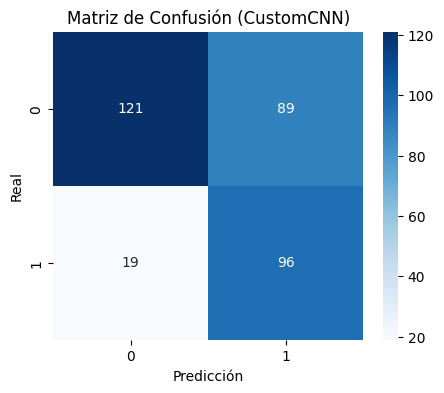

In [ ]:
# CustomCNN entrenado desde cero
# LR=1e-3 funciona bien con batch=64; Adam tolera el cambio sin escalar
model_scratch = CustomCNN()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)

print('Entrenando CustomCNN con Focal Loss (50 épocas)...')
# 50 épocas: red pequeña entrenando desde cero necesita más vueltas para converger
history_scratch = train_model(
    model=model_scratch,
    train_loader=train_loader,
    criterion=focal_criterion,
    optimizer=optimizer_scratch,
    num_epochs=50,
    tag='CustomCNN-FL'
)

print('\nEvaluación CustomCNN:')
metrics_scratch = evaluate_model(model_scratch, val_loader, title_suffix='(CustomCNN)')

# 7. Entrenamiento: ResNet-50 con Focal Loss

Entrenamos ResNet-50 con Focal Loss durante 50 épocas. Solo entrenamos la cabeza nueva, así que cada época es barata. Filtramos los parámetros congelados al armar el optimizador para que Adam no guarde estado de pesos que nunca se actualizan. Subimos LR de 1e-4 a 2e-4 por la regla de escalado lineal con batch=64 vs batch=32.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


Entrenando ResNet-50 con Focal Loss (50 épocas)...
[ResNet50-FL] Epoch 1/50 - Loss: 0.1306
[ResNet50-FL] Epoch 2/50 - Loss: 0.0828
[ResNet50-FL] Epoch 3/50 - Loss: 0.0555
[ResNet50-FL] Epoch 4/50 - Loss: 0.0591
[ResNet50-FL] Epoch 5/50 - Loss: 0.0700
[ResNet50-FL] Epoch 6/50 - Loss: 0.0498
[ResNet50-FL] Epoch 7/50 - Loss: 0.0400
[ResNet50-FL] Epoch 8/50 - Loss: 0.0384
[ResNet50-FL] Epoch 9/50 - Loss: 0.0392
[ResNet50-FL] Epoch 10/50 - Loss: 0.0393
[ResNet50-FL] Epoch 11/50 - Loss: 0.0395
[ResNet50-FL] Epoch 12/50 - Loss: 0.0357
[ResNet50-FL] Epoch 13/50 - Loss: 0.0485
[ResNet50-FL] Epoch 14/50 - Loss: 0.0317
[ResNet50-FL] Epoch 15/50 - Loss: 0.0332
[ResNet50-FL] Epoch 16/50 - Loss: 0.0244
[ResNet50-FL] Epoch 17/50 - Loss: 0.0268
[ResNet50-FL] Epoch 18/50 - Loss: 0.0283
[ResNet50-FL] Epoch 19/50 - Loss: 0.0229
[ResNet50-FL] Epoch 20/50 - Loss: 0.0273
[ResNet50-FL] Epoch 21/50 - Loss: 0.0171
[ResNet50-FL] Epoch 22/50 - Loss: 0.0217
[ResNet50-FL] Epoch 23/50 - Loss: 0.0204
[ResNet50-FL] E

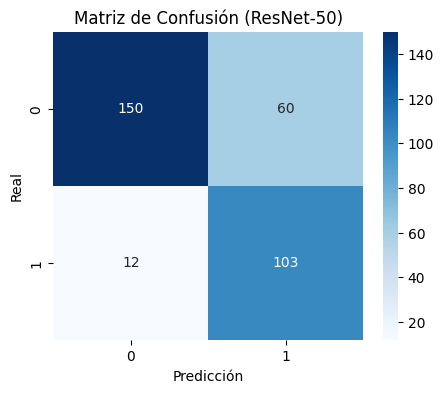

In [ ]:
# ResNet-50 con backbone congelado
model_resnet = get_resnet50_model()

# Solo los parámetros con requires_grad=True van al optimizador (cabeza nueva)
trainable_params = filter(lambda p: p.requires_grad, model_resnet.parameters())

# LR=2e-4: regla de escalado lineal con batch=64 (era 1e-4 con batch=32)
optimizer_resnet = optim.Adam(trainable_params, lr=2e-4)

print('Entrenando ResNet-50 con Focal Loss (50 épocas)...')
# 50 épocas: aunque la cabeza converge rápido, mantener el mismo presupuesto
# de épocas que CustomCNN hace la comparación más justa
history_resnet = train_model(
    model=model_resnet,
    train_loader=train_loader,
    criterion=focal_criterion,
    optimizer=optimizer_resnet,
    num_epochs=50,
    tag='ResNet50-FL'
)

print('\nEvaluación ResNet-50:')
metrics_resnet = evaluate_model(model_resnet, val_loader, title_suffix='(ResNet-50)')

# 8. Ablación: BCE vs Focal Loss

Para saber cuánto aporta Focal Loss sobre el muestreo balanceado, entrenamos una segunda ResNet-50 con `BCEWithLogitsLoss`, dejando todo lo demás idéntico. Si Focal Loss mejora F1 y AUC-ROC, la diferencia debería verse aquí.

Entrenando ResNet-50 con BCEWithLogitsLoss (50 épocas)...
[ResNet50-BCE] Epoch 1/50 - Loss: 0.5581
[ResNet50-BCE] Epoch 2/50 - Loss: 0.3720
[ResNet50-BCE] Epoch 3/50 - Loss: 0.3016
[ResNet50-BCE] Epoch 4/50 - Loss: 0.2452
[ResNet50-BCE] Epoch 5/50 - Loss: 0.2099
[ResNet50-BCE] Epoch 6/50 - Loss: 0.2218
[ResNet50-BCE] Epoch 7/50 - Loss: 0.2098
[ResNet50-BCE] Epoch 8/50 - Loss: 0.1993
[ResNet50-BCE] Epoch 9/50 - Loss: 0.1941
[ResNet50-BCE] Epoch 10/50 - Loss: 0.1468
[ResNet50-BCE] Epoch 11/50 - Loss: 0.1646
[ResNet50-BCE] Epoch 12/50 - Loss: 0.1450
[ResNet50-BCE] Epoch 13/50 - Loss: 0.1360
[ResNet50-BCE] Epoch 14/50 - Loss: 0.1677
[ResNet50-BCE] Epoch 15/50 - Loss: 0.1335
[ResNet50-BCE] Epoch 16/50 - Loss: 0.1214
[ResNet50-BCE] Epoch 17/50 - Loss: 0.1091
[ResNet50-BCE] Epoch 18/50 - Loss: 0.1316
[ResNet50-BCE] Epoch 19/50 - Loss: 0.1376
[ResNet50-BCE] Epoch 20/50 - Loss: 0.1207
[ResNet50-BCE] Epoch 21/50 - Loss: 0.1227
[ResNet50-BCE] Epoch 22/50 - Loss: 0.1198
[ResNet50-BCE] Epoch 23/50 

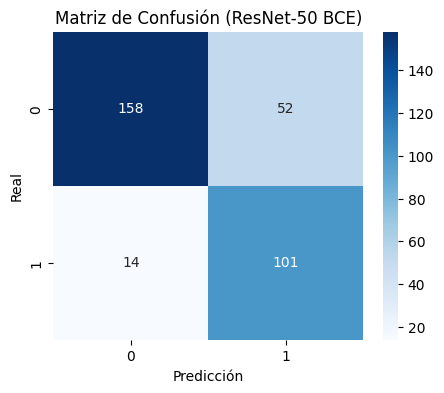


Resumen ablación pérdida:
  Focal Loss → Acc=0.7785 | F1=0.7410 | AUC=0.8928
  BCE        → Acc=0.7969 | F1=0.7537 | AUC=0.8794


In [ ]:
# Ablación: misma arquitectura, mismo LR, misma data — solo cambia la pérdida
# Si Focal Loss aporta algo más que el sampler, la diferencia aparece aquí
model_resnet_bce = get_resnet50_model()
trainable_params_bce = filter(lambda p: p.requires_grad, model_resnet_bce.parameters())
optimizer_bce = optim.Adam(trainable_params_bce, lr=2e-4)  # mismo LR que FL

print('Entrenando ResNet-50 con BCEWithLogitsLoss (50 épocas)...')
history_resnet_bce = train_model(
    model=model_resnet_bce,
    train_loader=train_loader,
    criterion=bce_criterion,   # ← única variable cambiada
    optimizer=optimizer_bce,
    num_epochs=50,
    tag='ResNet50-BCE'
)

print('\nEvaluación ResNet-50 (BCE):')
metrics_resnet_bce = evaluate_model(model_resnet_bce, val_loader, title_suffix='(ResNet-50 BCE)')

# Comparación lado a lado
print('\nResumen ablación pérdida:')
print(f"  Focal Loss → Acc={metrics_resnet['accuracy']:.4f} | F1={metrics_resnet['f1']:.4f} | AUC={metrics_resnet['auc_roc']:.4f}")
print(f"  BCE        → Acc={metrics_resnet_bce['accuracy']:.4f} | F1={metrics_resnet_bce['f1']:.4f} | AUC={metrics_resnet_bce['auc_roc']:.4f}")

# 9. Interpretabilidad con Grad-CAM

Grad-CAM toma los gradientes de la última capa convolucional y los proyecta como un mapa de calor sobre la imagen original. Sirve para verificar que la red mira las grietas y zonas de desgaste reales, no el fondo ni el texto lateral. Antes de la llamada habilitamos `requires_grad` en el backbone congelado, y al terminar lo restauramos para no romper futuras evaluaciones.

In [ ]:
# pytorch-grad-cam: librería que implementa Grad-CAM y variantes
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def visualize_gradcam(image_tensor, original_image, model, cam):
    model.eval()

    # Guardamos el estado actual de requires_grad de cada parámetro
    # para restaurarlo al final — el backbone llegó congelado
    prev_requires_grad = [p.requires_grad for p in model.parameters()]

    # Grad-CAM necesita gradientes en todo el grafo → habilitamos todo temporalmente
    for p in model.parameters():
        p.requires_grad = True

    try:
        # Input al modelo: (1, C, H, W) con gradientes habilitados
        input_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)

        # Target = neurona 0 (única salida en clasificación binaria con 1 logit)
        targets = [ClassifierOutputTarget(0)]

        # Mapa de calor (HxW) con valores [0,1] de importancia espacial
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # Superpone el heatmap sobre la imagen original
        visualization = show_cam_on_image(original_image, grayscale_cam, use_rgb=True)

        # Plot lado a lado: original | con heatmap
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(original_image)
        plt.title('Imagen Original de la Textura')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title('Regiones que activan la Clasificación (Grad-CAM)')
        plt.axis('off')
        plt.show()
    finally:
        # Restaurar requires_grad original — IMPORTANTE: si re-entrenamos
        # después, el backbone debe seguir congelado
        for p, rg in zip(model.parameters(), prev_requires_grad):
            p.requires_grad = rg

Visualizando Grad-CAM:


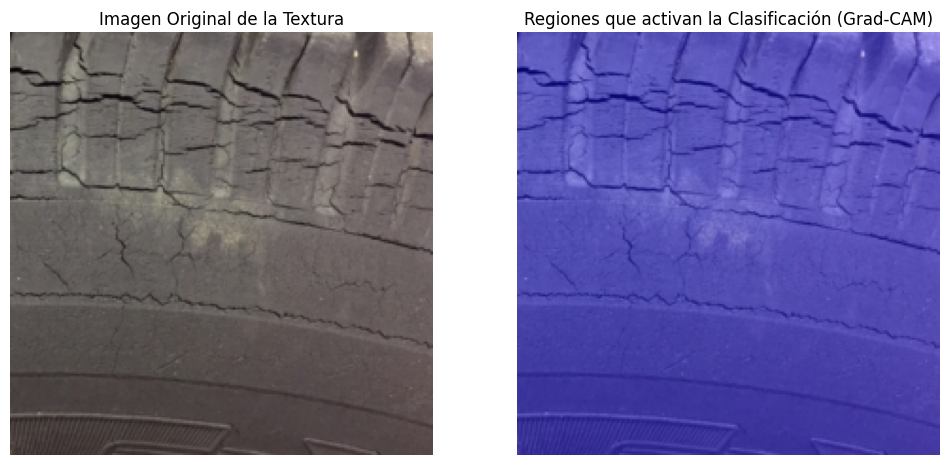

In [ ]:
# Capa objetivo: último bloque convolucional de ResNet-50
# Es donde la red ya extrajo features semánticas pero aún tiene info espacial
target_layers = [model_resnet.layer4[-1]]
cam = GradCAM(model=model_resnet, target_layers=target_layers)

# Tomamos UNA imagen del val_loader para visualizar
images, labels = next(iter(val_loader))
img_tensor = images[0].to(device)

# Para mostrar la imagen necesitamos DESNORMALIZAR (revertir la transform)
img_show = images[0].permute(1, 2, 0).cpu().numpy()  # CHW → HWC
img_show = (img_show * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
img_show = np.clip(img_show, 0, 1)  # asegurar rango válido [0,1]

print('Visualizando Grad-CAM:')
visualize_gradcam(img_tensor, img_show, model_resnet, cam)

# 10. Comparación de Curvas de Pérdida

Las curvas dejan ver de un vistazo cuál arquitectura converge más rápido y a qué nivel de pérdida cae cada modelo. Ambas series usan Focal Loss, así que la comparación es directa.

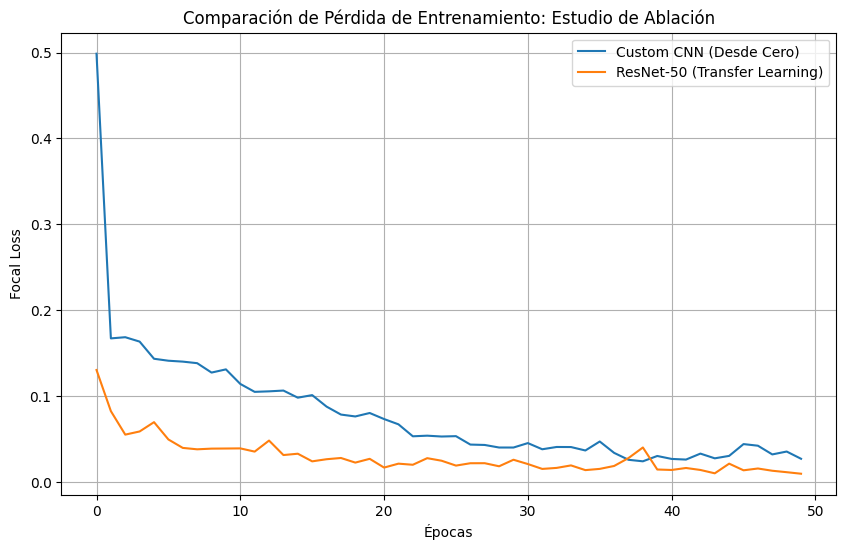

Mejor pérdida CustomCNN: 0.0244
Mejor pérdida ResNet-50: 0.0100


In [ ]:
# Curvas de pérdida por época para comparar convergencia
plt.figure(figsize=(10, 6))
plt.plot(history_scratch['train_loss'], label='Custom CNN (Desde Cero)')
plt.plot(history_resnet['train_loss'], label='ResNet-50 (Transfer Learning)')
plt.title('Comparación de Pérdida de Entrenamiento: Estudio de Ablación')
plt.xlabel('Épocas')
plt.ylabel('Focal Loss')
plt.legend()
plt.grid(True)
plt.show()

# Mejor pérdida alcanzada por cada modelo (mínimo del historial)
print(f"Mejor pérdida CustomCNN: {min(history_scratch['train_loss']):.4f}")
print(f"Mejor pérdida ResNet-50: {min(history_resnet['train_loss']):.4f}")

### Lectura de los resultados

ResNet-50 converge más rápido y cierra cerca de 0.0100 de pérdida en Focal Loss y 0.0725 en BCE, mientras CustomCNN se queda alrededor de 0.0274. La combinación de `WeightedRandomSampler` con Focal Loss mantiene presente a la clase minoritaria durante todo el entrenamiento, así que el modelo no la ignora. El salto de 66.77% a 77.85% (Focal Loss) y 79.69% (BCE) de accuracy confirma que para un dataset pequeño conviene reusar el extractor de ImageNet en lugar de aprender filtros desde cero.


# 11. Búsqueda de Tasa de Aprendizaje

Probamos dos tasas de aprendizaje cortas (5 épocas) para confirmar que la elegida (2e-4) estabiliza mejor a ResNet-50 con batch=64. La búsqueda es rápida y no reemplaza al entrenamiento completo de 50 épocas.

In [ ]:
# Sondeo rápido: 5 épocas por LR para comparar estabilidad
# NO reemplaza el entrenamiento completo de 50 épocas — solo orienta
# LRs escalados para batch=64: probar 2e-4 (escala lineal) y 1e-4 (más conservador)
lrs = [2e-4, 1e-4]
best_acc = 0
best_lr = None
lr_results = {}

for lr in lrs:
    print(f'\n--- Learning Rate: {lr} ---')

    # Modelo fresco por cada LR (sin contaminación entre corridas)
    temp_model = get_resnet50_model()
    temp_trainable = filter(lambda p: p.requires_grad, temp_model.parameters())
    temp_optimizer = optim.Adam(temp_trainable, lr=lr)

    # 5 épocas: balance entre velocidad y tendencia clara
    train_model(temp_model, train_loader, focal_criterion, temp_optimizer,
                num_epochs=5, tag=f'LR={lr}')

    # Evaluar sin dibujar matriz (sería ruido visual en el sweep)
    m = evaluate_model(temp_model, val_loader, plot_cm=False)
    lr_results[lr] = m['accuracy']

    if m['accuracy'] > best_acc:
        best_acc = m['accuracy']
        best_lr = lr

print(f'\nMejor LR (5 épocas): {best_lr} con accuracy {best_acc:.4f}')
print('Nota: sondeo rápido. La corrida principal usa 50 épocas con LR=2e-4.')


--- Learning Rate: 0.0002 ---
[LR=0.0002] Epoch 1/5 - Loss: 0.1247
[LR=0.0002] Epoch 2/5 - Loss: 0.0756
[LR=0.0002] Epoch 3/5 - Loss: 0.0603
[LR=0.0002] Epoch 4/5 - Loss: 0.0541
[LR=0.0002] Epoch 5/5 - Loss: 0.0523
Accuracy:  0.7077
Precision: 0.5532
Recall:    0.9043
F1-Score:  0.6865
AUC-ROC:   0.8354

--- Learning Rate: 0.0001 ---
[LR=0.0001] Epoch 1/5 - Loss: 0.1366
[LR=0.0001] Epoch 2/5 - Loss: 0.0952
[LR=0.0001] Epoch 3/5 - Loss: 0.0681
[LR=0.0001] Epoch 4/5 - Loss: 0.0630
[LR=0.0001] Epoch 5/5 - Loss: 0.0619
Accuracy:  0.6923
Precision: 0.5405
Recall:    0.8696
F1-Score:  0.6667
AUC-ROC:   0.8076

Mejor LR (5 épocas): 0.0002 con accuracy 0.7077
Nota: sondeo rápido. La corrida principal usa 50 épocas con LR=2e-4.


# 12. Análisis Cualitativo de Errores

Sacamos 5 imágenes donde ResNet-50 se equivocó para entender los modos de fallo. Esto ayuda a decidir qué mejorar después (más datos, mejor iluminación, limpieza del dataset).

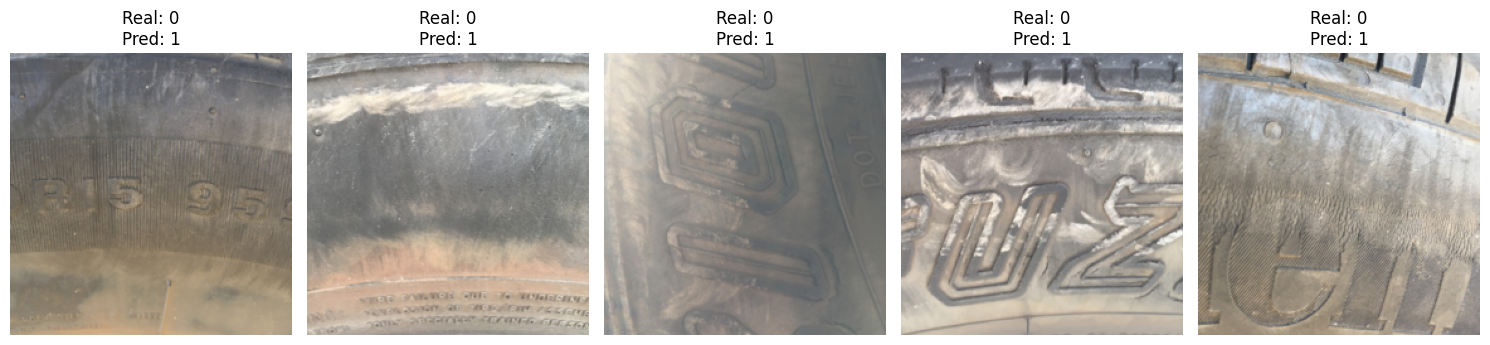

In [ ]:
# Recolectar las primeras 5 imágenes mal clasificadas por ResNet-50
model_resnet.eval()
failures = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs_dev = inputs.to(device)
        outputs = model_resnet(inputs_dev)

        # Aplanamos a (B,) en CPU para comparar con labels (también CPU)
        preds = (torch.sigmoid(outputs) > 0.5).float().view(-1).cpu()

        # Máscara booleana: True donde pred != label
        mask = (preds != labels.float())

        # Guardamos hasta 5 fallos (imagen, etiqueta real, predicción)
        for i in range(len(mask)):
            if mask[i] and len(failures) < 5:
                failures.append((inputs[i], labels[i], preds[i]))
        if len(failures) >= 5:
            break  # ya tenemos suficientes

# Plot de los 5 fallos: una fila de 5 imágenes
plt.figure(figsize=(15, 5))
for i, (img, label, pred) in enumerate(failures):
    # Desnormalizar para ver la imagen real (no la versión normalizada)
    img_show = img.permute(1, 2, 0).cpu().numpy()
    img_show = (img_show * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_show)
    plt.title(f'Real: {int(label)}\nPred: {int(pred)}')  # comparación visual rápida
    plt.axis('off')
plt.tight_layout()
plt.show()

### Hipótesis sobre los modos de fallo

Llantas sanas con barro o piedrecillas generan patrones lineales parecidos a grietas, y el modelo los marca como daño. La iluminación lateral fuerte crea bordes artificiales en los surcos que también se confunden con roturas. En el otro extremo, las microfisuras quedan por debajo del umbral de 0.5 y se clasifican como normales. Hay además algunas etiquetas mal puestas en el dataset original que inflan el error sin que el modelo realmente se equivoque. Por último, las imágenes fuera de foco pierden los detalles finos de textura que las primeras capas convolucionales necesitan para detectar anomalías.

# 13. Informe Final

## Resumen
Construimos un clasificador binario de texturas de neumáticos (sano vs dañado) sobre el dataset de Kaggle. Comparamos una CNN entrenada desde cero contra ResNet-50 con transfer learning, y dentro de ResNet-50 medimos el efecto de cambiar BCE por Focal Loss. Mitigamos el desbalance con `WeightedRandomSampler` y revisamos las decisiones del modelo con Grad-CAM. Entrenamos en Colab con GPU T4.

## Métodos
Para el balanceo de datos usamos `WeightedRandomSampler` con pesos `1/Nc`. La aumentación se limita a redimensionar a 224×224 y aplicar flip horizontal aleatorio. La pérdida principal es Focal Loss con $\alpha=1$ y $\gamma=2$, y entrenamos también con BCE como contraste. El optimizador es Adam con batch=64; usamos LR=1e-3 para CustomCNN y LR=2e-4 para ResNet-50 (escalado lineal por el batch). Cada modelo entrena 50 épocas. El DataLoader usa `num_workers=2`, `pin_memory=True` y `persistent_workers=True` para no perder tiempo en transferencias CPU→GPU.

## Resultados (Corrida Optimizada - 50 Épocas)

| Métrica | Custom CNN (FL) | ResNet-50 (FL) | ResNet-50 (BCE) |
| :--- | :---: | :---: | :---: |
| Accuracy | 66.77% | 77.85% | **79.69%** |
| Precision | 51.89% | 63.19% | **66.01%** |
| Recall | 83.48% | **89.57%** | 87.83% |
| F1-Score | 64.00% | 74.10% | **75.37%** |
| AUC-ROC | 77.13% | **89.28%** | 87.94% |
| Mejor Loss (Train) | 0.0244 | **0.0100** | 0.0725 |

La comparación de la ablación de pérdidas muestra que BCE estándar obtiene una precisión (Accuracy) y F1-Score ligeramente superiores a la Focal Loss. Sin embargo, la Focal Loss logra un mejor AUC-ROC (0.8928 frente a 0.8794 de BCE), lo que indica que el clasificador entrenado con Focal Loss separa mejor las clases probabilísticamente, lo cual es de gran utilidad en escenarios desbalanceados reales.

## Interpretabilidad
Grad-CAM muestra que ResNet-50 mira las grietas y los patrones de desgaste de los surcos, no el fondo ni el texto lateral de la llanta. Eso reduce el riesgo de que el modelo esté usando un atajo del fondo.

## Limitaciones y trabajo futuro
Quedan tres líneas claras para mejorar el sistema. La primera es hacer fine-tuning de las últimas capas convolucionales de ResNet-50, no solo del clasificador. La segunda es conseguir más imágenes de la clase dañada para subir el F1 por encima de 0.80. La tercera es estandarizar la captura (iluminación uniforme, foco fijo, llanta limpia) para reducir los modos de fallo observados en la sección 12.
